In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
path='/ptmp/arego/RecordLenRedT/'
Track=pd.read_parquet(path)

In [3]:
path='/ptmp/arego/Record_Len_Tracks/out.parquet'
Track=pd.read_parquet(path)

In [4]:
path='/ptmp/arego/Record_Len_Cas/out.parquet'
cascade=pd.read_parquet(path)

In [5]:
path='/ptmp/arego/Record_Len_Single/out.parquet'
single=pd.read_parquet(path)

In [6]:
path='/ptmp/arego/Record_Len_Bio/out.parquet'
bio=pd.read_parquet(path)

In [7]:
path='/ptmp/arego/Record_Len_RedC/'
RedC=pd.read_parquet(path)

In [8]:
path='/ptmp/arego/Record_Len_RedT/'
RedT=pd.read_parquet(path)

In [9]:
path='/ptmp/arego/StatsEN_RedT/out.parquet'
Stats=pd.read_parquet(path)

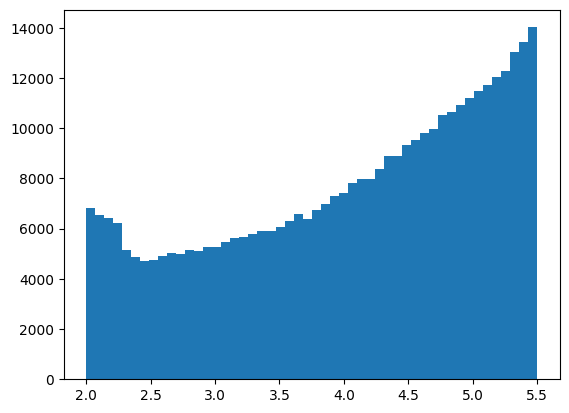

In [7]:
plt.hist(np.log10(Track['energy']),bins=50)
plt.show()

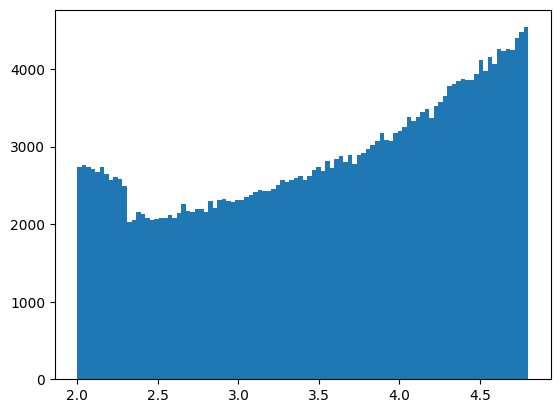

In [44]:
x = Track[(Track["duration"] == 0) | (Track["energy"] > 10**4.8)]
plt.hist(np.log10(x['energy']),bins=100)
plt.show()

In [48]:
track[(track.duration == 0) | (track.energy > 10**4.8)]

,file_id,record_id,duration,min_time,max_time,hit_count,energy
1,0,5,1040.935162,418.744998,1459.680159,562.0,156546.917481
4,0,9,102.686375,3624.122991,3726.809366,51.0,187393.051486
5,0,10,851.808775,1535.320747,2387.129522,4434.0,71694.763987
11,0,21,0.136719,4311.813385,4311.950103,3.0,309196.646701
12,0,22,418.967607,339.596880,758.564487,84.0,270971.543850
...,...,...,...,...,...,...,...
423873,33066,26,714.602281,367.453019,1082.055301,148.0,83818.614806
423875,33066,28,1112.868798,274.201988,1387.070786,13661.0,137649.781311
423882,33092,9,1042.339754,362.893897,1405.233651,8862.0,68291.003033
423894,33092,37,1851.466438,235.647993,2087.114431,5315.0,132891.434943


In [49]:
df=track[(track.duration == 0) | (track.energy > 10**4.8)][['file_id','record_id']]

In [28]:
df=RedT[(RedT.duration == 0) | (RedT.energy > 10**4.8)][['file_id','record_id']]

In [50]:
df

,file_id,record_id
1,0,5
4,0,9
5,0,10
11,0,21
12,0,22
...,...,...
423873,33066,26
423875,33066,28
423882,33092,9
423894,33092,37


In [27]:
df['file_id'].value_counts().sum()

134093

In [40]:
RedT['hit_count'].max()

284962520.0

In [56]:
track[track['hit_count']==2]['duration'].min()

8.19986507849535e-06

In [51]:
df.to_csv('Track_skiplist.csv',index=False)

In [46]:
cascade[(cascade.duration != 0) & (cascade.energy < 10**3.8)]

,file_id,record_id,duration,min_time,max_time,hit_count,energy
1,0,2,494.129247,94.066476,588.195724,4875.0,139.125691
10,0,18,424.958027,228.690876,653.648903,1821.0,125.637374
11,0,19,425.712821,382.095903,807.808724,709.0,272.264782
15,0,23,1120.985272,181.903363,1302.888635,26166.0,2202.274448
19,0,28,27.064557,499.614455,526.679012,14.0,2297.338464
...,...,...,...,...,...,...,...
707270,36247,19,572.277052,189.818347,762.095399,2385.0,193.962225
707272,36247,23,1109.991791,272.592756,1382.584547,59346.0,2775.394325
707276,36247,31,1166.708168,156.600509,1323.308677,33596.0,5326.470606
707278,36247,34,579.891875,247.096478,826.988353,2681.0,626.020427


In [18]:
hits.groupby("record_id")["time"].agg(lambda x: x.max() - x.min())

record_id
0     1165.752760
5      596.292023
7        0.000000
8     1511.416442
9     1409.006992
11    1502.935988
12    1009.422505
13    1537.661553
14     715.932635
15    3923.572282
16    1658.654052
17    1460.454132
20    1057.768680
23    1881.979202
24     294.848018
25    6143.506967
27      61.129743
28    1911.209134
29       0.082204
30    1168.547064
Name: time, dtype: float64

In [51]:
df.groupby("record_id")["time"].agg(lambda x: x.max() - x.min())

record_id
0     6999.875000
5     6999.764067
7     6999.750000
8     6999.290525
9     6999.936553
12    6999.750000
13    6999.875000
14    6999.687500
17    6999.875000
23    6999.764067
24    6999.402979
25    7621.653513
27    6999.482585
30    6999.303591
31    6999.733368
32    6999.875000
33    6999.733368
34    6999.303591
35    6999.482585
36    6999.500000
Name: time, dtype: float64

In [9]:
data=df[df['record_id']==25]
data
# plt.scatter(data['time'],data['type'])
# plt.show()

,time,string_id,module_id,pmt_id,record_id,type
1906505,2609.544389,0,0,0,25,2
1906506,2609.486094,0,0,0,25,2
1906507,2609.803115,0,0,0,25,2
1906508,2609.485870,0,0,0,25,2
1906509,2609.487782,0,0,0,25,2
...,...,...,...,...,...,...
161413823,1618.368719,13,19,5,25,21
161413824,3458.368719,13,19,5,25,21
161413825,5468.868719,13,19,5,25,21
161413826,3103.368719,13,19,3,25,21


In [14]:
data[data['type']==2]['time'].max()-data[data['type']==2]['time'].min()

7543.096385023287

In [15]:
data[data['type']!=2]['time'].max()-data[data['type']!=2]['time'].min()

6999.5

In [38]:
RedT[RedT['duration']>7000]

,file_id,record_id,duration,min_time,max_time,hit_count,energy
311,16,25,7621.653513,933.868719,8555.522231,159507323.0,64086.212797
394,20,48,7026.266482,391.801351,7418.067832,1298084.0,726.392103
888,53,25,7627.415857,536.373704,8163.789561,176559840.0,129501.414381
894,53,38,7427.291589,281.983967,7709.275556,176524238.0,129501.414381
1447,83,18,7000.000000,1761.813567,8761.813567,448222.0,8114.619792
...,...,...,...,...,...,...,...
384429,23151,28,7000.000000,1247.900865,8247.900865,353155.0,331.984207
384434,23151,36,7000.000000,1345.620195,8345.620195,347892.0,116.227483
388185,23376,10,7000.000000,1300.885017,8300.885017,385259.0,4462.202157
388987,26442,17,7000.000000,2027.407726,9027.407726,378646.0,297.293507


In [8]:
import matplotlib.pyplot as plt
import numpy as np

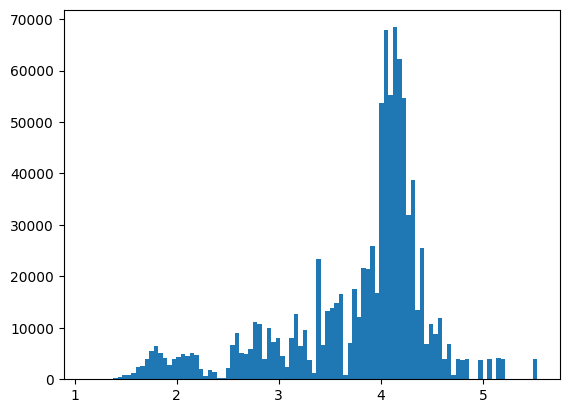

In [9]:
plt.hist(np.log10(bio['hit_count']),bins=100)
plt.show()

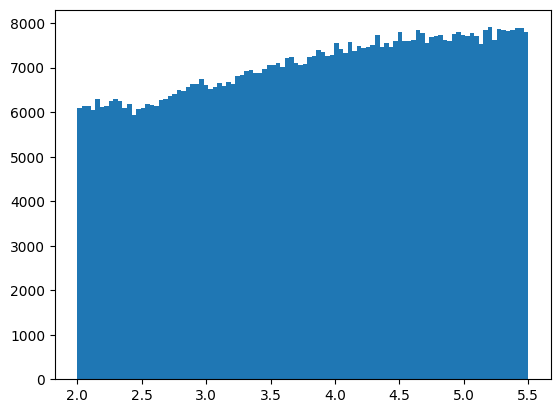

In [10]:
plt.hist(np.log10(cascade['energy']),bins=100)
plt.show()

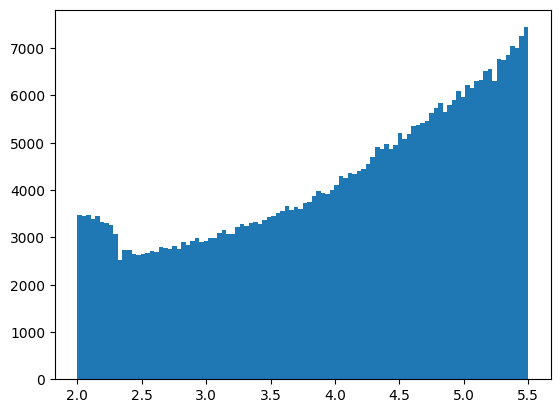

In [11]:
plt.hist(np.log10(track['energy']),bins=100)
plt.show()

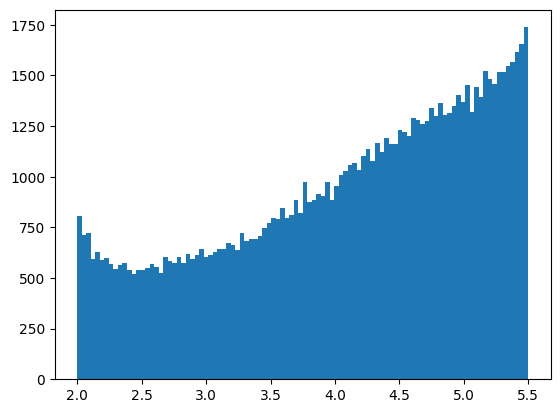

In [12]:
plt.hist(np.log10(single['energy']),bins=100)
plt.show()

In [13]:
energies=np.array([])
for i in range(20_000):
    rng=np.random.default_rng(i)
    energies=np.append(energies,np.power(10, rng.uniform(2, 5.5, size=20)))

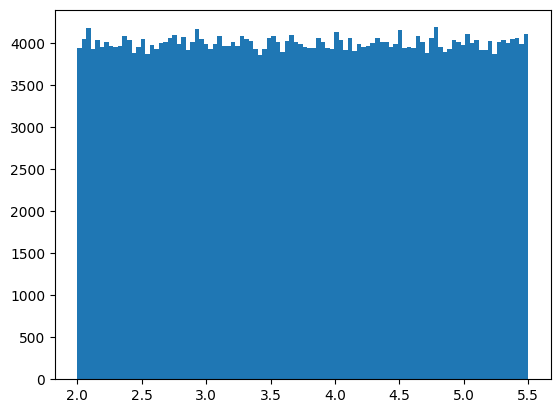

In [14]:
plt.hist(np.log10(energies),bins=100)
plt.show()

In [15]:
path='/raven/ptmp/arego/stat_merge_bio/merge.npy'

data=np.load(path)
data=data.reshape(data.shape[0]*data.shape[1],2)
arr=data[:,1]

path='/raven/ptmp/arego/stat_merge_electrical/merge.npy'

data=np.load(path)
data=data.reshape(data.shape[0]*data.shape[1],2)
arr=arr+data[arr.shape,1]

mean = np.mean(arr)
median = np.median(arr)
std_dev = np.std(arr)
variance = np.var(arr)

print("Mean:", np.log10(mean))
print("Median:", np.log10(median))
print("Standard Deviation:", np.log10(std_dev))
print("Variance:", np.log10(variance))

Mean: 4.058380296040672
Median: 3.966986025117938
Standard Deviation: 4.195817777778323
Variance: 8.391635555556647


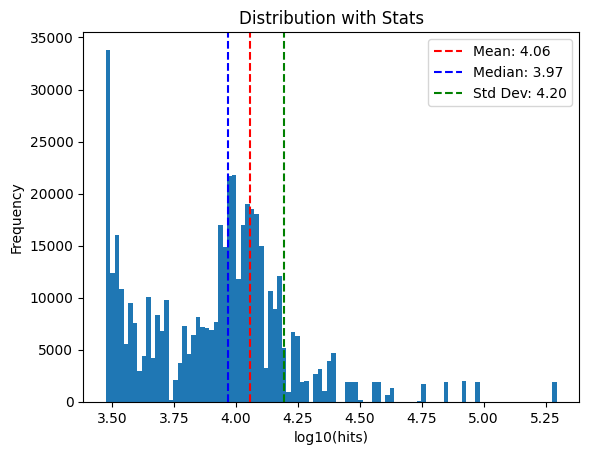

In [16]:
vals = {
    "Mean": np.log10(mean),
    "Median": np.log10(median),
    "Std Dev": np.log10(std_dev),
}

# plot histogram
plt.hist(np.log10(arr), bins=100)

# add vertical lines
colors = ["red", "blue", "green", "orange"]

for (label, v), c in zip(vals.items(), colors):
    plt.axvline(v, linestyle="--", color=c, label=f"{label}: {v:.2f}")


plt.legend()
plt.title("Distribution with Stats")
plt.xlabel("log10(hits)")
plt.ylabel("Frequency")
plt.show()

In [17]:
track[track['hit_count']==1].shape[0]/track.shape[0]*100

1.4545883463080915

In [18]:
t=track[track['hit_count']<5*std_dev]
t[t['hit_count']>8].shape[0]/track.shape[0]*100

81.11299834866715

In [19]:
t=cascade[cascade['hit_count']<5*std_dev]
t[t['hit_count']>8].shape[0]/cascade.shape[0]*100

57.84993213437394

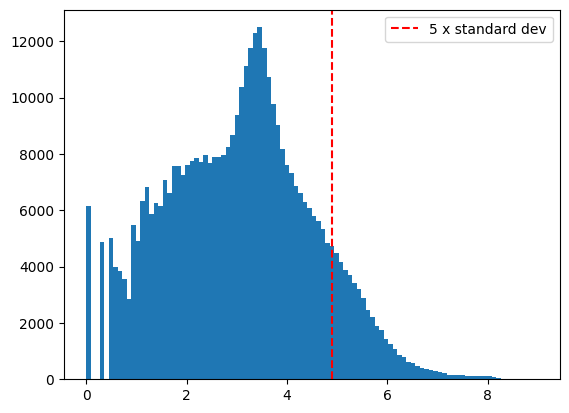

In [20]:
plt.hist(np.log10(track['hit_count']),bins=100)
plt.axvline(np.log10(std_dev*5), linestyle="--", color='red', label=f"5 x standard dev")
plt.legend()
plt.show()

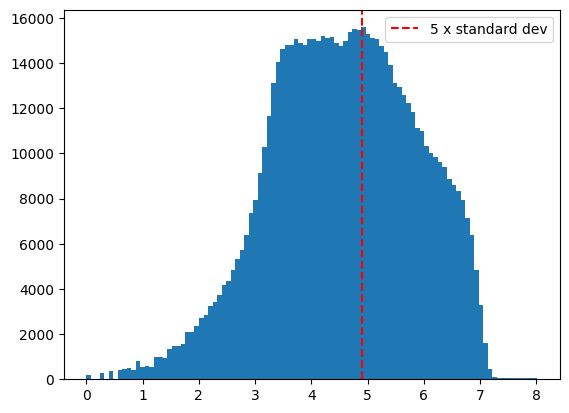

In [21]:
plt.hist(np.log10(cascade['hit_count']),bins=100)
plt.axvline(np.log10(std_dev*5), linestyle="--", color='red', label=f"5 x standard dev")
plt.legend()
plt.show()

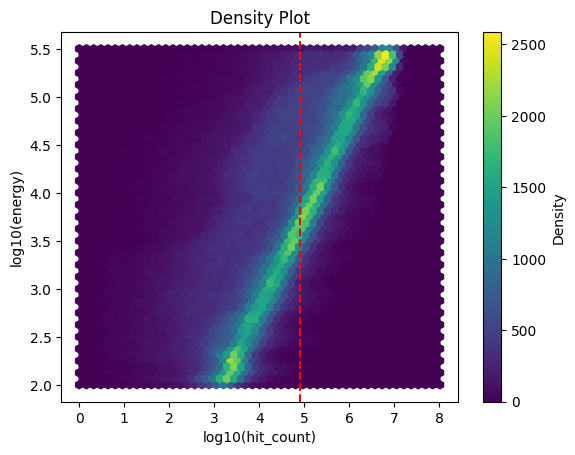

In [22]:
import matplotlib.pyplot as plt

plt.hexbin(
    np.log10(cascade['hit_count']),
    np.log10(cascade['energy']),
    gridsize=50,
    cmap="viridis"
)
plt.axvline(np.log10(std_dev*5), linestyle="--", color='red', label=f"5 x standard dev")
plt.colorbar(label="Density")
plt.xlabel("log10(hit_count)")
plt.ylabel("log10(energy)")
plt.title("Density Plot")
plt.show()


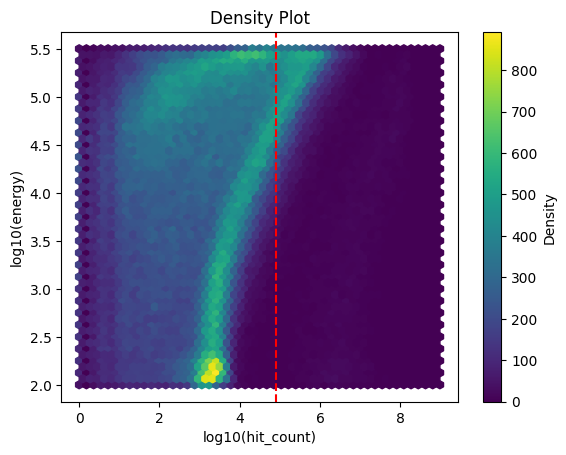

In [23]:
import matplotlib.pyplot as plt

plt.hexbin(
    np.log10(track['hit_count']),
    np.log10(track['energy']),
    gridsize=50,
    cmap="viridis"
)
plt.axvline(np.log10(std_dev*5), linestyle="--", color='red', label=f"5 x standard dev")
plt.colorbar(label="Density")
plt.xlabel("log10(hit_count)")
plt.ylabel("log10(energy)")
plt.title("Density Plot")
plt.show()


3881.1959228515625


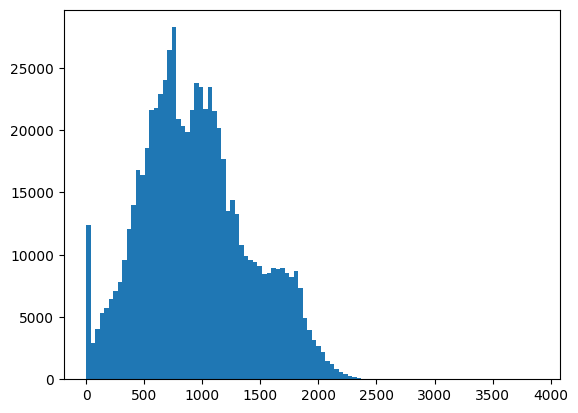

In [24]:
plt.hist((cascade['duration']+1),bins=100)
print(cascade['duration'].max())
plt.show()

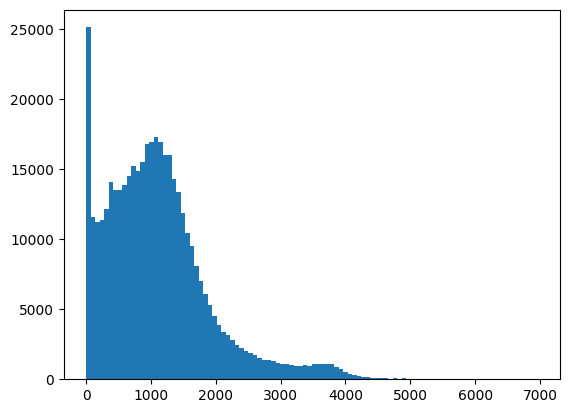

In [25]:
plt.hist((track['duration']+1),bins=100)
plt.show()

In [26]:
track['duration'].max()

6954.271917676024

In [27]:
arr = track['duration']

mean = np.mean(arr)
median = np.median(arr)
std_dev = np.std(arr)
variance = np.var(arr)

print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std_dev)


Mean: 1112.407348105083
Median: 1009.1271222047341
Standard Deviation: 819.5600997918849
